importing libraries



In [1]:
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt
import seaborn as sns

loading our dataset student_data


In [2]:
students=pd.read_excel("student_data.xlsx")

In [3]:
students.head()

,Student_ID,Gender,Programme,Year_of_Study,Admission_Type,Age,Attendance_Rate,Assignment_Score,Exam_Score,Study_Hours_per_Week,Internet_Access,Device_Type,Family_Income,Stress_Level,GPA,Scholarship,Dropped_Out
0,10001,Male,Analytics,3,Regular,25,70.828212,76.000473,80.296648,6.372859,Yes,Tablet,12556.507447,Medium,3.330362,No,No
1,10002,Female,Economics,2,Regular,21,69.942178,67.248610,29.469632,23.825097,Yes,Mobile,22569.129727,High,3.117031,No,No
2,10003,Male,Accounting,2,Mature,17,63.280549,62.309827,76.874813,52.669848,Yes,Laptop,NaN,Medium,2.851835,No,Yes
3,10004,Male,Economics,1,Regular,22,59.625115,70.270440,48.218508,2.147296,Yes,Mobile,11975.627487,Low,3.045307,No,No
4,10005,Male,Analytics,2,Regular,23,92.749857,48.872435,91.505367,10.385678,Yes,Laptop,24628.109128,Low,2.438924,No,No


inspecting data types

In [4]:
students.dtypes

Student_ID                int64
Gender                   object
Programme                object
Year_of_Study             int64
Admission_Type           object
Age                       int64
Attendance_Rate         float64
Assignment_Score        float64
Exam_Score              float64
Study_Hours_per_Week    float64
Internet_Access          object
Device_Type              object
Family_Income           float64
Stress_Level             object
GPA                     float64
Scholarship              object
Dropped_Out              object
dtype: object

In [5]:
students.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Student_ID            1200 non-null   int64  
 1   Gender                1200 non-null   object 
 2   Programme             1200 non-null   object 
 3   Year_of_Study         1200 non-null   int64  
 4   Admission_Type        1200 non-null   object 
 5   Age                   1200 non-null   int64  
 6   Attendance_Rate       1104 non-null   float64
 7   Assignment_Score      1104 non-null   float64
 8   Exam_Score            1200 non-null   float64
 9   Study_Hours_per_Week  1200 non-null   float64
 10  Internet_Access       1200 non-null   object 
 11  Device_Type           1200 non-null   object 
 12  Family_Income         1104 non-null   float64
 13  Stress_Level          1200 non-null   object 
 14  GPA                   1200 non-null   float64
 15  Scholarship          

checking for missing values

In [6]:
students.isnull().any()


Student_ID              False
Gender                  False
Programme               False
Year_of_Study           False
Admission_Type          False
Age                     False
Attendance_Rate          True
Assignment_Score         True
Exam_Score              False
Study_Hours_per_Week    False
Internet_Access         False
Device_Type             False
Family_Income            True
Stress_Level            False
GPA                     False
Scholarship             False
Dropped_Out             False
dtype: bool

In [7]:
students.isnull().mean()

Student_ID              0.00
Gender                  0.00
Programme               0.00
Year_of_Study           0.00
Admission_Type          0.00
Age                     0.00
Attendance_Rate         0.08
Assignment_Score        0.08
Exam_Score              0.00
Study_Hours_per_Week    0.00
Internet_Access         0.00
Device_Type             0.00
Family_Income           0.08
Stress_Level            0.00
GPA                     0.00
Scholarship             0.00
Dropped_Out             0.00
dtype: float64

In [8]:
students.isnull().sum()

Student_ID               0
Gender                   0
Programme                0
Year_of_Study            0
Admission_Type           0
Age                      0
Attendance_Rate         96
Assignment_Score        96
Exam_Score               0
Study_Hours_per_Week     0
Internet_Access          0
Device_Type              0
Family_Income           96
Stress_Level             0
GPA                      0
Scholarship              0
Dropped_Out              0
dtype: int64

checking the distributions for the missing columns

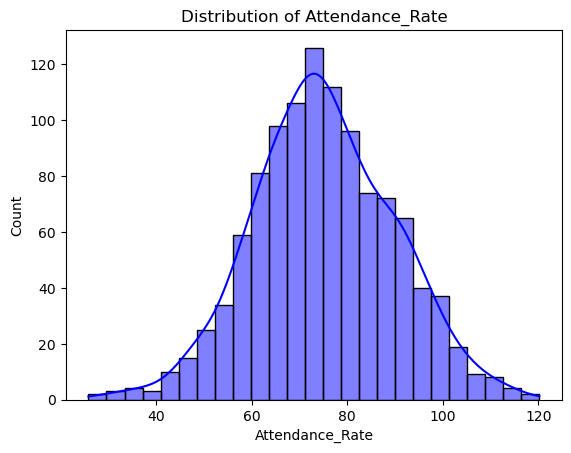

In [9]:
sns.histplot(students['Attendance_Rate'].dropna(), kde=True, color='blue')
plt.title('Distribution of Attendance_Rate')
plt.show()

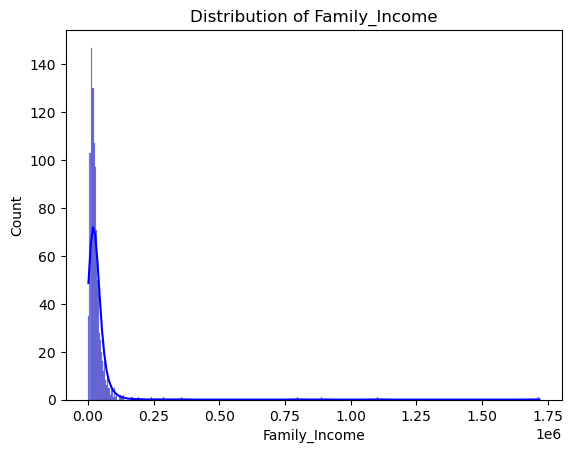

In [10]:
sns.histplot(students['Family_Income'].dropna(), kde=True, color='blue')
plt.title('Distribution of Family_Income')
plt.show()

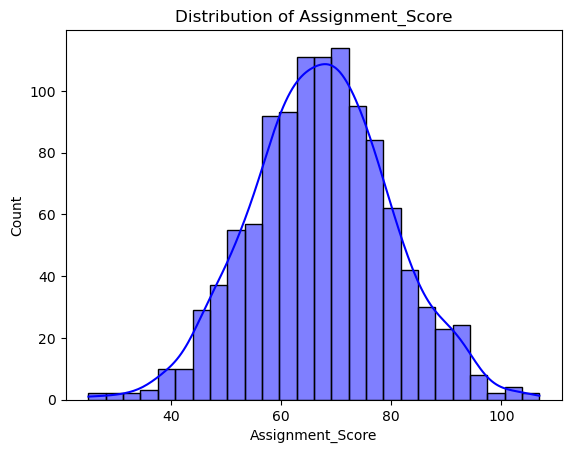

In [11]:
sns.histplot(students['Assignment_Score'].dropna(), kde=True, color='blue')
plt.title('Distribution of Assignment_Score')
plt.show()

For the data quality issues, 
1. The data is not complete since it has missing values.

For the data profilinhg,
1. Loading the dataset helps us to understand the structure and also examine the quality of data
2. By examining this dataset, we are able to identify the data types, missing values, anf the distributions of the columns with missing values which helps us to determine data cleaning and transformation steps to follow subsequently.

Task 2, handling missing data
For columns with missing values,

In [12]:
students.isnull().any()

Student_ID              False
Gender                  False
Programme               False
Year_of_Study           False
Admission_Type          False
Age                     False
Attendance_Rate          True
Assignment_Score         True
Exam_Score              False
Study_Hours_per_Week    False
Internet_Access         False
Device_Type             False
Family_Income            True
Stress_Level            False
GPA                     False
Scholarship             False
Dropped_Out             False
dtype: bool

In [13]:
students[['Attendance_Rate','Assignment_Score','Family_Income']]

,Attendance_Rate,Assignment_Score,Family_Income
0,70.828212,76.000473,12556.507447
1,69.942178,67.248610,22569.129727
2,63.280549,62.309827,NaN
3,59.625115,70.270440,11975.627487
4,92.749857,48.872435,24628.109128
...,...,...,...
1195,75.327986,57.495676,17244.677199
1196,86.809838,62.522032,22827.838448
1197,NaN,83.413245,35867.843198
1198,75.641744,80.526145,16463.953819


Handling missing values, we will use the imputations method
For Attendance_Rate and Assignment_Score, we will use the end of distribution value to fill the missing areas since they are normally distributed.
For the Family_Income, we will use the mean_value to fill the missing areas since it is not noramlly distributed

In [14]:
mean_ar=students['Attendance_Rate'].mean()
print(mean_ar)

75.1114059837123


In [15]:
mean_as=students['Assignment_Score'].mean()
print(mean_as)

67.28674182356599


In [16]:
mean_fi=students['Family_Income'].mean()
print(mean_fi)

32130.094647270653


In [17]:
std_ar=students['Attendance_Rate'].std()
print(std_ar)

14.756455168888658


In [18]:
std_as=students['Assignment_Score'].std()
print(std_as)

12.583584063107189


In [19]:
eod_ar=mean_ar + 3*std_ar
print(eod_ar)

119.38077149037828


In [20]:
eod_as=mean_as + 3*std_as
print(eod_as)

105.03749401288755


In [21]:
students.describe()

,Student_ID,Year_of_Study,Age,Attendance_Rate,Assignment_Score,Exam_Score,Study_Hours_per_Week,Family_Income,GPA
count,1200.000000,1200.000000,1200.000000,1104.000000,1104.000000,1200.000000,1200.000000,1.104000e+03,1200.000000
mean,10600.500000,2.516667,21.940833,75.111406,67.286742,64.941923,8.227369,3.213009e+04,3.010974
std,346.554469,1.134664,3.944232,14.756455,12.583584,15.371361,9.762074,7.414182e+04,0.493046
min,10001.000000,1.000000,9.000000,25.874840,25.015249,14.786741,0.001927,1.962593e+03,1.000000
25%,10300.750000,2.000000,19.000000,65.397679,58.979074,54.554959,2.332424,1.343185e+04,2.686602
50%,10600.500000,2.000000,22.000000,74.248008,67.437808,64.812662,5.521229,2.171679e+04,3.031096
75%,10900.250000,4.000000,25.000000,84.967446,75.536026,75.278729,11.068604,3.367431e+04,3.356756
max,11200.000000,4.000000,34.000000,120.220676,106.881670,114.145990,165.783799,1.718758e+06,4.000000


fiiling in the missing values for Attendance_Rate, Family_Income, Assignment_Score
                             

In [22]:
students['Attendance_Rate'].fillna(eod_ar, inplace=True)
students['Assignment_Score'].fillna(eod_as, inplace=True)
students['Family_Income'].fillna(mean_fi, inplace=True)
students.head(50)

C:\Users\Clement\AppData\Local\Temp\ipykernel_20740\2261005887.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  students['Attendance_Rate'].fillna(eod_ar, inplace=True)
C:\Users\Clement\AppData\Local\Temp\ipykernel_20740\2261005887.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a co

,Student_ID,Gender,Programme,Year_of_Study,Admission_Type,Age,Attendance_Rate,Assignment_Score,Exam_Score,Study_Hours_per_Week,Internet_Access,Device_Type,Family_Income,Stress_Level,GPA,Scholarship,Dropped_Out
0,10001,Male,Analytics,3,Regular,25,70.828212,76.000473,80.296648,6.372859,Yes,Tablet,12556.507447,Medium,3.330362,No,No
1,10002,Female,Economics,2,Regular,21,69.942178,67.248610,29.469632,23.825097,Yes,Mobile,22569.129727,High,3.117031,No,No
2,10003,Male,Accounting,2,Mature,17,63.280549,62.309827,76.874813,52.669848,Yes,Laptop,32130.094647,Medium,2.851835,No,Yes
3,10004,Male,Economics,1,Regular,22,59.625115,70.270440,48.218508,2.147296,Yes,Mobile,11975.627487,Low,3.045307,No,No
4,10005,Male,Analytics,2,Regular,23,92.749857,48.872435,91.505367,10.385678,Yes,Laptop,24628.109128,Low,2.438924,No,No
5,10006,Female,Analytics,4,Regular,20,100.108524,65.476136,49.036329,3.798921,No,Laptop,28418.054331,Medium,3.414608,No,Yes
6,10007,Male,Business,1,Regular,27,60.222084,38.341281,52.208568,0.065130,Yes,Mobile,17380.687319,Low,3.808981,Yes,No
7,10008,Male,Analytics,2,Regular,20,96.074135,47.890499,73.436356,0.074365,Yes,Laptop,32130.094647,Medium,2.401201,No,No
8,10009,Male,Business,1,Regular,26,67.689159,46.085770,74.884312,4.937879,Yes,Laptop,26496.873307,Medium,2.210374,No,No
9,10010,Female,Accounting,3,Regular,24,83.004720,80.568221,58.305019,5.360680,Yes,Laptop,8966.962592,High,2.798956,No,No


In [23]:
students.isnull().sum()

Student_ID              0
Gender                  0
Programme               0
Year_of_Study           0
Admission_Type          0
Age                     0
Attendance_Rate         0
Assignment_Score        0
Exam_Score              0
Study_Hours_per_Week    0
Internet_Access         0
Device_Type             0
Family_Income           0
Stress_Level            0
GPA                     0
Scholarship             0
Dropped_Out             0
dtype: int64

Encoding

In [24]:
#Printing out the unique values for the categorical variables,
print(students['Gender'].unique())
print(students['Internet_Access'].unique())
print(students['Scholarship'].unique())
print(students['Dropped_Out'].unique())
print(students['Device_Type'].unique())
print(students['Programme'].unique())
print(students['Stress_Level'].unique())
print(students['Admission_Type'].unique())




['Male' 'Female']
['Yes' 'No']
['No' 'Yes']
['No' 'Yes']
['Tablet' 'Mobile' 'Laptop']
['Analytics' 'Economics' 'Accounting' 'Business' 'MIS']
['Medium' 'High' 'Low']
['Regular' 'Mature' 'International']


For the binary categorical variables, we will make use of LabelEncoding
These includes;Gender, Internet_Access, Scholarship and Dropped_Out

In [25]:
#For Gender
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
students['le_Gender']=le.fit_transform(students['Gender'])
students.head()

,Student_ID,Gender,Programme,Year_of_Study,Admission_Type,Age,Attendance_Rate,Assignment_Score,Exam_Score,Study_Hours_per_Week,Internet_Access,Device_Type,Family_Income,Stress_Level,GPA,Scholarship,Dropped_Out,le_Gender
0,10001,Male,Analytics,3,Regular,25,70.828212,76.000473,80.296648,6.372859,Yes,Tablet,12556.507447,Medium,3.330362,No,No,1
1,10002,Female,Economics,2,Regular,21,69.942178,67.248610,29.469632,23.825097,Yes,Mobile,22569.129727,High,3.117031,No,No,0
2,10003,Male,Accounting,2,Mature,17,63.280549,62.309827,76.874813,52.669848,Yes,Laptop,32130.094647,Medium,2.851835,No,Yes,1
3,10004,Male,Economics,1,Regular,22,59.625115,70.270440,48.218508,2.147296,Yes,Mobile,11975.627487,Low,3.045307,No,No,1
4,10005,Male,Analytics,2,Regular,23,92.749857,48.872435,91.505367,10.385678,Yes,Laptop,24628.109128,Low,2.438924,No,No,1


In [26]:
#For Internet_Access
le=LabelEncoder()
students['le_IA']=le.fit_transform(students['Internet_Access'])
students.head()

,Student_ID,Gender,Programme,Year_of_Study,Admission_Type,Age,Attendance_Rate,Assignment_Score,Exam_Score,Study_Hours_per_Week,Internet_Access,Device_Type,Family_Income,Stress_Level,GPA,Scholarship,Dropped_Out,le_Gender,le_IA
0,10001,Male,Analytics,3,Regular,25,70.828212,76.000473,80.296648,6.372859,Yes,Tablet,12556.507447,Medium,3.330362,No,No,1,1
1,10002,Female,Economics,2,Regular,21,69.942178,67.248610,29.469632,23.825097,Yes,Mobile,22569.129727,High,3.117031,No,No,0,1
2,10003,Male,Accounting,2,Mature,17,63.280549,62.309827,76.874813,52.669848,Yes,Laptop,32130.094647,Medium,2.851835,No,Yes,1,1
3,10004,Male,Economics,1,Regular,22,59.625115,70.270440,48.218508,2.147296,Yes,Mobile,11975.627487,Low,3.045307,No,No,1,1
4,10005,Male,Analytics,2,Regular,23,92.749857,48.872435,91.505367,10.385678,Yes,Laptop,24628.109128,Low,2.438924,No,No,1,1


In [27]:
#For Scholarship
le=LabelEncoder()
students['le_Scholarship']=le.fit_transform(students['Scholarship'])
students.head()

,Student_ID,Gender,Programme,Year_of_Study,Admission_Type,Age,Attendance_Rate,Assignment_Score,Exam_Score,Study_Hours_per_Week,Internet_Access,Device_Type,Family_Income,Stress_Level,GPA,Scholarship,Dropped_Out,le_Gender,le_IA,le_Scholarship
0,10001,Male,Analytics,3,Regular,25,70.828212,76.000473,80.296648,6.372859,Yes,Tablet,12556.507447,Medium,3.330362,No,No,1,1,0
1,10002,Female,Economics,2,Regular,21,69.942178,67.248610,29.469632,23.825097,Yes,Mobile,22569.129727,High,3.117031,No,No,0,1,0
2,10003,Male,Accounting,2,Mature,17,63.280549,62.309827,76.874813,52.669848,Yes,Laptop,32130.094647,Medium,2.851835,No,Yes,1,1,0
3,10004,Male,Economics,1,Regular,22,59.625115,70.270440,48.218508,2.147296,Yes,Mobile,11975.627487,Low,3.045307,No,No,1,1,0
4,10005,Male,Analytics,2,Regular,23,92.749857,48.872435,91.505367,10.385678,Yes,Laptop,24628.109128,Low,2.438924,No,No,1,1,0


In [28]:
#For Dropped_Out
le=LabelEncoder()
students['le_DO']=le.fit_transform(students['Dropped_Out'])
students.head()

,Student_ID,Gender,Programme,Year_of_Study,Admission_Type,Age,Attendance_Rate,Assignment_Score,Exam_Score,Study_Hours_per_Week,...,Device_Type,Family_Income,Stress_Level,GPA,Scholarship,Dropped_Out,le_Gender,le_IA,le_Scholarship,le_DO
0,10001,Male,Analytics,3,Regular,25,70.828212,76.000473,80.296648,6.372859,...,Tablet,12556.507447,Medium,3.330362,No,No,1,1,0,0
1,10002,Female,Economics,2,Regular,21,69.942178,67.248610,29.469632,23.825097,...,Mobile,22569.129727,High,3.117031,No,No,0,1,0,0
2,10003,Male,Accounting,2,Mature,17,63.280549,62.309827,76.874813,52.669848,...,Laptop,32130.094647,Medium,2.851835,No,Yes,1,1,0,1
3,10004,Male,Economics,1,Regular,22,59.625115,70.270440,48.218508,2.147296,...,Mobile,11975.627487,Low,3.045307,No,No,1,1,0,0
4,10005,Male,Analytics,2,Regular,23,92.749857,48.872435,91.505367,10.385678,...,Laptop,24628.109128,Low,2.438924,No,No,1,1,0,0


In [29]:
students.head()

,Student_ID,Gender,Programme,Year_of_Study,Admission_Type,Age,Attendance_Rate,Assignment_Score,Exam_Score,Study_Hours_per_Week,...,Device_Type,Family_Income,Stress_Level,GPA,Scholarship,Dropped_Out,le_Gender,le_IA,le_Scholarship,le_DO
0,10001,Male,Analytics,3,Regular,25,70.828212,76.000473,80.296648,6.372859,...,Tablet,12556.507447,Medium,3.330362,No,No,1,1,0,0
1,10002,Female,Economics,2,Regular,21,69.942178,67.248610,29.469632,23.825097,...,Mobile,22569.129727,High,3.117031,No,No,0,1,0,0
2,10003,Male,Accounting,2,Mature,17,63.280549,62.309827,76.874813,52.669848,...,Laptop,32130.094647,Medium,2.851835,No,Yes,1,1,0,1
3,10004,Male,Economics,1,Regular,22,59.625115,70.270440,48.218508,2.147296,...,Mobile,11975.627487,Low,3.045307,No,No,1,1,0,0
4,10005,Male,Analytics,2,Regular,23,92.749857,48.872435,91.505367,10.385678,...,Laptop,24628.109128,Low,2.438924,No,No,1,1,0,0


We will use One hot encoding for Admission_Type,Programme,Device_Type since they have more than two unique values


In [30]:
encoding=pd.get_dummies(students['Admission_Type'], dtype=int) 
print(encoding)

      International  Mature  Regular
0                 0       0        1
1                 0       0        1
2                 0       1        0
3                 0       0        1
4                 0       0        1
...             ...     ...      ...
1195              0       0        1
1196              0       0        1
1197              0       0        1
1198              0       0        1
1199              0       0        1

[1200 rows x 3 columns]


In [31]:
students=pd.concat([students ,encoding], axis=1)
students.head()

,Student_ID,Gender,Programme,Year_of_Study,Admission_Type,Age,Attendance_Rate,Assignment_Score,Exam_Score,Study_Hours_per_Week,...,GPA,Scholarship,Dropped_Out,le_Gender,le_IA,le_Scholarship,le_DO,International,Mature,Regular
0,10001,Male,Analytics,3,Regular,25,70.828212,76.000473,80.296648,6.372859,...,3.330362,No,No,1,1,0,0,0,0,1
1,10002,Female,Economics,2,Regular,21,69.942178,67.248610,29.469632,23.825097,...,3.117031,No,No,0,1,0,0,0,0,1
2,10003,Male,Accounting,2,Mature,17,63.280549,62.309827,76.874813,52.669848,...,2.851835,No,Yes,1,1,0,1,0,1,0
3,10004,Male,Economics,1,Regular,22,59.625115,70.270440,48.218508,2.147296,...,3.045307,No,No,1,1,0,0,0,0,1
4,10005,Male,Analytics,2,Regular,23,92.749857,48.872435,91.505367,10.385678,...,2.438924,No,No,1,1,0,0,0,0,1


In [32]:
p_encoding=pd.get_dummies(students['Programme'], dtype=int) 
print(p_encoding)

      Accounting  Analytics  Business  Economics  MIS
0              0          1         0          0    0
1              0          0         0          1    0
2              1          0         0          0    0
3              0          0         0          1    0
4              0          1         0          0    0
...          ...        ...       ...        ...  ...
1195           1          0         0          0    0
1196           0          1         0          0    0
1197           0          0         0          1    0
1198           0          0         0          0    1
1199           0          1         0          0    0

[1200 rows x 5 columns]


In [33]:
students=pd.concat([students ,p_encoding], axis=1)
students.head()

,Student_ID,Gender,Programme,Year_of_Study,Admission_Type,Age,Attendance_Rate,Assignment_Score,Exam_Score,Study_Hours_per_Week,...,le_Scholarship,le_DO,International,Mature,Regular,Accounting,Analytics,Business,Economics,MIS
0,10001,Male,Analytics,3,Regular,25,70.828212,76.000473,80.296648,6.372859,...,0,0,0,0,1,0,1,0,0,0
1,10002,Female,Economics,2,Regular,21,69.942178,67.248610,29.469632,23.825097,...,0,0,0,0,1,0,0,0,1,0
2,10003,Male,Accounting,2,Mature,17,63.280549,62.309827,76.874813,52.669848,...,0,1,0,1,0,1,0,0,0,0
3,10004,Male,Economics,1,Regular,22,59.625115,70.270440,48.218508,2.147296,...,0,0,0,0,1,0,0,0,1,0
4,10005,Male,Analytics,2,Regular,23,92.749857,48.872435,91.505367,10.385678,...,0,0,0,0,1,0,1,0,0,0


In [34]:
students_dt=pd.get_dummies(students['Device_Type'], dtype=int) 
print(students_dt)

      Laptop  Mobile  Tablet
0          0       0       1
1          0       1       0
2          1       0       0
3          0       1       0
4          1       0       0
...      ...     ...     ...
1195       1       0       0
1196       0       1       0
1197       0       1       0
1198       1       0       0
1199       1       0       0

[1200 rows x 3 columns]


In [35]:
students=pd.concat([students ,students_dt], axis=1)
students.head()

,Student_ID,Gender,Programme,Year_of_Study,Admission_Type,Age,Attendance_Rate,Assignment_Score,Exam_Score,Study_Hours_per_Week,...,Mature,Regular,Accounting,Analytics,Business,Economics,MIS,Laptop,Mobile,Tablet
0,10001,Male,Analytics,3,Regular,25,70.828212,76.000473,80.296648,6.372859,...,0,1,0,1,0,0,0,0,0,1
1,10002,Female,Economics,2,Regular,21,69.942178,67.248610,29.469632,23.825097,...,0,1,0,0,0,1,0,0,1,0
2,10003,Male,Accounting,2,Mature,17,63.280549,62.309827,76.874813,52.669848,...,1,0,1,0,0,0,0,1,0,0
3,10004,Male,Economics,1,Regular,22,59.625115,70.270440,48.218508,2.147296,...,0,1,0,0,0,1,0,0,1,0
4,10005,Male,Analytics,2,Regular,23,92.749857,48.872435,91.505367,10.385678,...,0,1,0,1,0,0,0,1,0,0


In [36]:
#For Stress_Level we will use the ordinal encoding since the unique values appear orderly
from sklearn.preprocessing import OrdinalEncoder
logical_order = ['Low', 'Medium', 'High']
encoded = OrdinalEncoder(categories=[logical_order])
students["Stress_Level_Encoded"] = encoded.fit_transform(students[["Stress_Level"]])
students.head()

,Student_ID,Gender,Programme,Year_of_Study,Admission_Type,Age,Attendance_Rate,Assignment_Score,Exam_Score,Study_Hours_per_Week,...,Regular,Accounting,Analytics,Business,Economics,MIS,Laptop,Mobile,Tablet,Stress_Level_Encoded
0,10001,Male,Analytics,3,Regular,25,70.828212,76.000473,80.296648,6.372859,...,1,0,1,0,0,0,0,0,1,1.0
1,10002,Female,Economics,2,Regular,21,69.942178,67.248610,29.469632,23.825097,...,1,0,0,0,1,0,0,1,0,2.0
2,10003,Male,Accounting,2,Mature,17,63.280549,62.309827,76.874813,52.669848,...,0,1,0,0,0,0,1,0,0,1.0
3,10004,Male,Economics,1,Regular,22,59.625115,70.270440,48.218508,2.147296,...,1,0,0,0,1,0,0,1,0,0.0
4,10005,Male,Analytics,2,Regular,23,92.749857,48.872435,91.505367,10.385678,...,1,0,1,0,0,0,1,0,0,0.0


In [37]:
students[['Stress_Level','Stress_Level_Encoded']]

,Stress_Level,Stress_Level_Encoded
0,Medium,1.0
1,High,2.0
2,Medium,1.0
3,Low,0.0
4,Low,0.0
...,...,...
1195,Medium,1.0
1196,Low,0.0
1197,Low,0.0
1198,High,2.0


Data Discretization

In [38]:
students['GPA']

0       3.330362
1       3.117031
2       2.851835
3       3.045307
4       2.438924
          ...   
1195    1.720562
1196    2.733159
1197    3.173303
1198    2.719441
1199    2.350996
Name: GPA, Length: 1200, dtype: float64

C:\Users\Clement\AppData\Local\Temp\ipykernel_20740\2358821711.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(students['GPA'], kde=True)


<Axes: xlabel='GPA', ylabel='Density'>

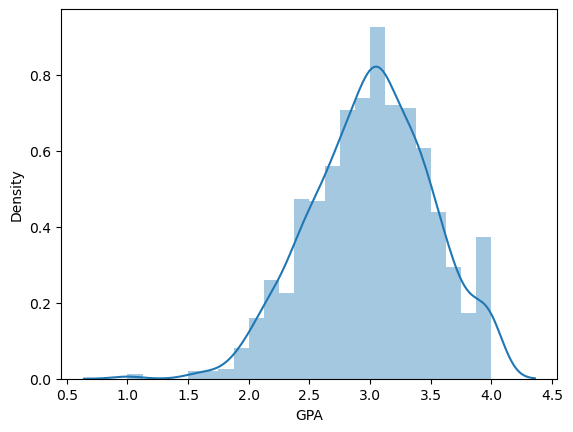

In [39]:
sns.distplot(students['GPA'], kde=True)

In [40]:
students['Family_Income']

0       12556.507447
1       22569.129727
2       32130.094647
3       11975.627487
4       24628.109128
            ...     
1195    17244.677199
1196    22827.838448
1197    35867.843198
1198    16463.953819
1199    42171.846626
Name: Family_Income, Length: 1200, dtype: float64

C:\Users\Clement\AppData\Local\Temp\ipykernel_20740\3559548742.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(students['Family_Income'], kde=True)


<Axes: xlabel='Family_Income', ylabel='Density'>

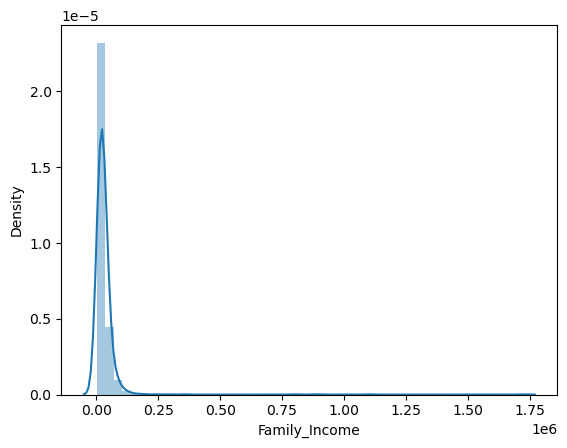

In [41]:
sns.distplot(students['Family_Income'], kde=True)

In [42]:
#for GPA,
gpa_range=students['GPA'].max()- students['GPA'].min()
print(gpa_range)

3.0


In [43]:
gpa_range/4

0.75

In [44]:
lower_interval=int(np.floor(students['GPA'].min()))
upper_interval=int(np.ceil(students['GPA'].max()))

interval_length=int(np.round(gpa_range/4))

print(lower_interval)
print(upper_interval)
print(interval_length)

1
4
1


In [45]:
total_bins=[i for i in range(lower_interval, upper_interval+interval_length, interval_length)]
print(total_bins)

[1, 2, 3, 4]


In [46]:
bin_labels=['Bin_no_'+str(i) for i in range(1, len(total_bins))]
print(bin_labels)

['Bin_no_1', 'Bin_no_2', 'Bin_no_3']


In [47]:
students['gpa_bins']=pd.cut(x=students['GPA'],
bins=total_bins, labels=bin_labels, include_lowest=True)
students.head()

,Student_ID,Gender,Programme,Year_of_Study,Admission_Type,Age,Attendance_Rate,Assignment_Score,Exam_Score,Study_Hours_per_Week,...,Accounting,Analytics,Business,Economics,MIS,Laptop,Mobile,Tablet,Stress_Level_Encoded,gpa_bins
0,10001,Male,Analytics,3,Regular,25,70.828212,76.000473,80.296648,6.372859,...,0,1,0,0,0,0,0,1,1.0,Bin_no_3
1,10002,Female,Economics,2,Regular,21,69.942178,67.248610,29.469632,23.825097,...,0,0,0,1,0,0,1,0,2.0,Bin_no_3
2,10003,Male,Accounting,2,Mature,17,63.280549,62.309827,76.874813,52.669848,...,1,0,0,0,0,1,0,0,1.0,Bin_no_2
3,10004,Male,Economics,1,Regular,22,59.625115,70.270440,48.218508,2.147296,...,0,0,0,1,0,0,1,0,0.0,Bin_no_3
4,10005,Male,Analytics,2,Regular,23,92.749857,48.872435,91.505367,10.385678,...,0,1,0,0,0,1,0,0,0.0,Bin_no_2


In [48]:
students[['GPA','gpa_bins']]

,GPA,gpa_bins
0,3.330362,Bin_no_3
1,3.117031,Bin_no_3
2,2.851835,Bin_no_2
3,3.045307,Bin_no_3
4,2.438924,Bin_no_2
...,...,...
1195,1.720562,Bin_no_1
1196,2.733159,Bin_no_2
1197,3.173303,Bin_no_3
1198,2.719441,Bin_no_2


C:\Users\Clement\AppData\Local\Temp\ipykernel_20740\3903782358.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  students.groupby('gpa_bins')['GPA'].count().plot.bar()


(array([0, 1, 2]),
 [Text(0, 0, 'Bin_no_1'), Text(1, 0, 'Bin_no_2'), Text(2, 0, 'Bin_no_3')])

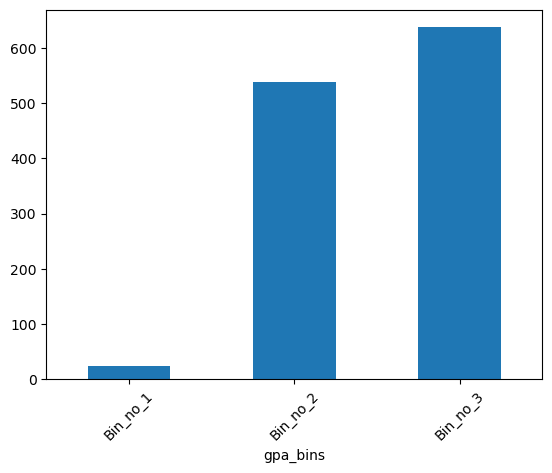

In [49]:
students.groupby('gpa_bins')['GPA'].count().plot.bar()
plt.xticks(rotation=45)

<Axes: xlabel='gpa_bins', ylabel='count'>

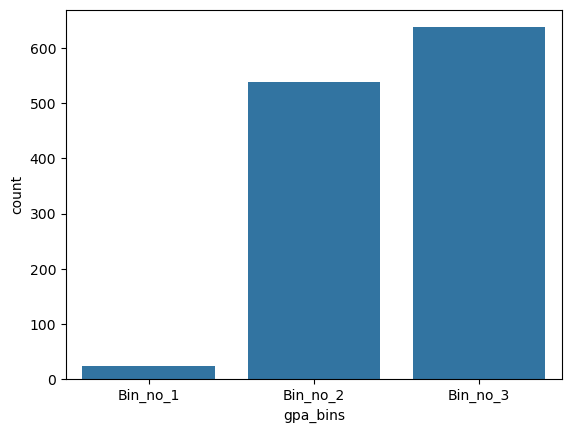

In [50]:
sns.countplot(x='gpa_bins',  data=students)

Discretization

Detecting outliers

<Axes: ylabel='Exam_Score'>

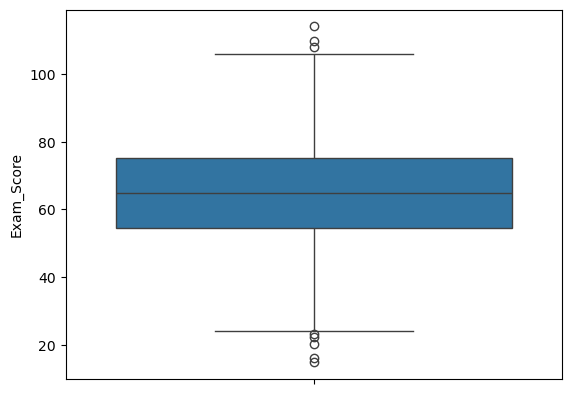

In [51]:
sns.boxplot( y='Exam_Score',data=students) 

In [52]:
Q1=students['Exam_Score'].quantile(0.25)
Q3=students['Exam_Score'].quantile(0.75)
IQR=Q3-Q1
print(IQR)

20.723769623820388


In [53]:
lower_bound= students['Exam_Score'].quantile(0.25)-(IQR*1.5)
upper_bound=students['Exam_Score'].quantile(0.75)+(IQR*1.5)

print(lower_bound)
print(upper_bound)

23.469304944496905
106.36438343977846


In [54]:
Exam_Score_outliers=np.where(students['Exam_Score']>upper_bound,True,
                      np.where(students['Exam_Score']<lower_bound, True,False))

Students_without_Exam_Score_outliers=students.loc[~(Exam_Score_outliers),]
students.shape,Students_without_Exam_Score_outliers.shape

((1200, 34), (1192, 34))

<Axes: ylabel='Exam_Score'>

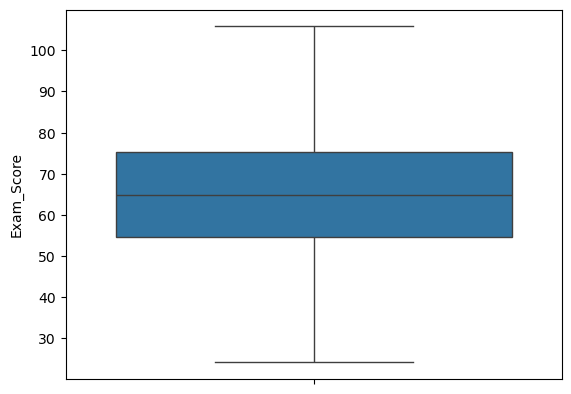

In [55]:
sns.boxplot(y='Exam_Score',data= Students_without_Exam_Score_outliers)

The trimming method was used in order to maintain the the actual position of the mean since extreme values pull the mean and standard deviaion away.

Feature Scaling

Standardization
This involves centering the data variable at 0 and standardizing the data variance at 1


In [56]:
students_data=students[['Assignment_Score',	'Exam_Score','Study_Hours_per_Week','Family_Income','GPA']]	
print(students_data)

      Assignment_Score  Exam_Score  Study_Hours_per_Week  Family_Income  \
0            76.000473   80.296648              6.372859   12556.507447   
1            67.248610   29.469632             23.825097   22569.129727   
2            62.309827   76.874813             52.669848   32130.094647   
3            70.270440   48.218508              2.147296   11975.627487   
4            48.872435   91.505367             10.385678   24628.109128   
...                ...         ...                   ...            ...   
1195         57.495676   39.273201              6.036350   17244.677199   
1196         62.522032   74.452694              3.105762   22827.838448   
1197         83.413245   31.371555              0.623883   35867.843198   
1198         80.526145   60.861268             18.080131   16463.953819   
1199         67.743856   39.416726             12.983258   42171.846626   

           GPA  
0     3.330362  
1     3.117031  
2     2.851835  
3     3.045307  
4     2.438924

In [57]:
students_data.describe()

,Assignment_Score,Exam_Score,Study_Hours_per_Week,Family_Income,GPA
count,1200.000000,1200.000000,1200.000000,1.200000e+03,1200.000000
mean,70.306802,64.941923,8.227369,3.213009e+04,3.010974
std,15.831758,15.371361,9.762074,7.111175e+04,0.493046
min,25.015249,14.786741,0.001927,1.962593e+03,1.000000
25%,59.694023,54.554959,2.332424,1.417420e+04,2.686602
50%,68.601528,64.812662,5.521229,2.328459e+04,3.031096
75%,78.235176,75.278729,11.068604,3.220706e+04,3.356756
max,106.881670,114.145990,165.783799,1.718758e+06,4.000000


In [58]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler.fit(students_data)
students_scaled=scaler.transform(students_data)


In [59]:
students_scaled=pd.DataFrame(students_scaled,
columns=students_data.columns)
students_scaled.head()

,Assignment_Score,Exam_Score,Study_Hours_per_Week,Family_Income,GPA
0,0.359786,0.999334,-0.190050,-2.753658e-01,0.648056
1,-0.193249,-2.308649,1.598454,-1.345059e-01,0.215195
2,-0.505333,0.776630,4.554463,-1.023599e-16,-0.322902
3,-0.002298,-1.088413,-0.623086,-2.835378e-01,0.069663
4,-1.354449,1.728833,0.221183,-1.055397e-01,-1.160722


<Axes: xlabel='GPA', ylabel='Density'>

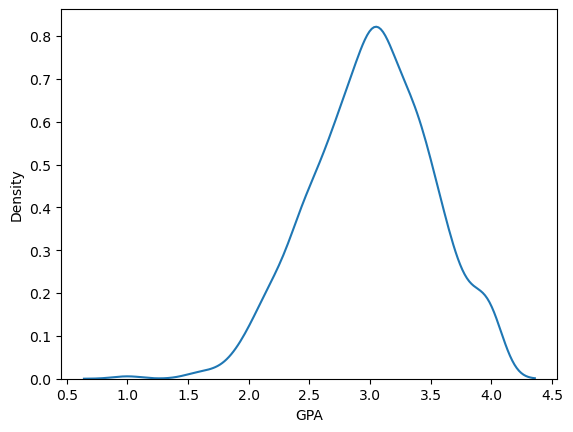

In [60]:
sns.kdeplot(students['GPA'])

<Axes: xlabel='GPA', ylabel='Density'>

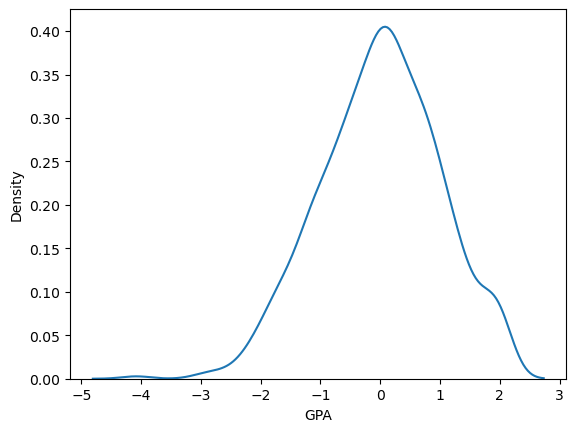

In [61]:
sns.kdeplot(students_scaled['GPA'])

Plotting the kernel density for the original and scaled data taking a column say GPA, it can be realised that standardization does not affect the default data distibution.

Normalization(Min/Max Scaling)
This invloves subtracting each value from the minimum value and dividing it by the results of the difference between and minimum and maximum value in a dataset

In [62]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
scaler.fit(students_data)
students_scaled=scaler.transform(students_data)

In [63]:
students_scaled=pd.DataFrame(students_scaled,
columns=students_data.columns)
students_scaled.head()                    

,Assignment_Score,Exam_Score,Study_Hours_per_Week,Family_Income,GPA
0,0.622786,0.659324,0.038430,0.006171,0.776787
1,0.515881,0.147776,0.143702,0.012003,0.705677
2,0.455554,0.624885,0.317694,0.017572,0.617278
3,0.552793,0.336474,0.012941,0.005832,0.681769
4,0.291416,0.772134,0.062635,0.013202,0.479641


<Axes: xlabel='GPA', ylabel='Density'>

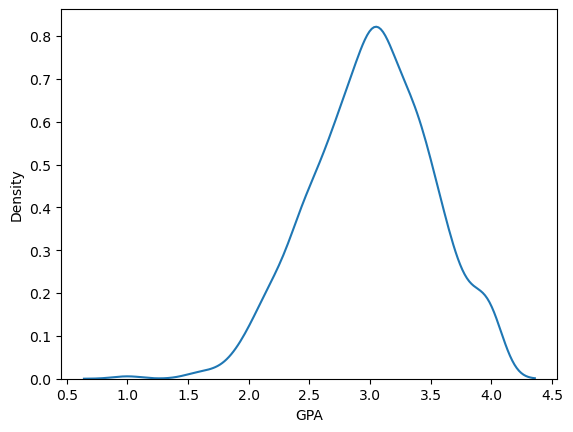

In [64]:
sns.kdeplot(students['GPA'])

<Axes: xlabel='GPA', ylabel='Density'>

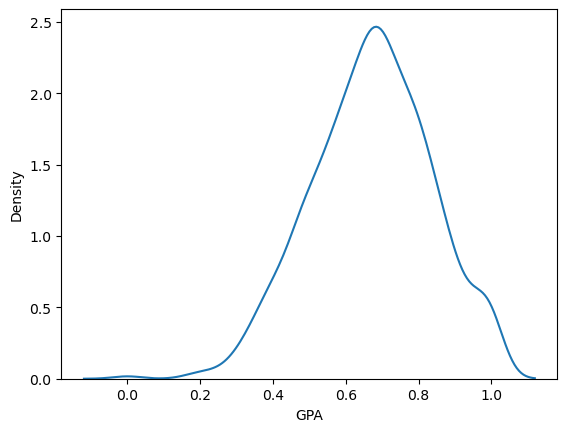

In [65]:
sns.kdeplot(students_scaled['GPA'])

Plotting the kernel density for the original and scaled data taking a column say GPA, it can be realised that normalization does not affect the default data distibution.

Mean Normalization
This invloves subtracting the mean from each value and results divided by the difference of the minimum and maximum values in the dataset 

In [66]:
mean_values=students_data.mean(axis=0)
print(mean_values)

Assignment_Score           70.306802
Exam_Score                 64.941923
Study_Hours_per_Week        8.227369
Family_Income           32130.094647
GPA                         3.010974
dtype: float64


In [67]:
range=students_data.max(axis=0)-students_data.min(axis=0)
print(range)

Assignment_Score        8.186642e+01
Exam_Score              9.935925e+01
Study_Hours_per_Week    1.657819e+02
Family_Income           1.716795e+06
GPA                     3.000000e+00
dtype: float64


In [68]:
students_scaled=(students_data-mean_values/range)
print(students_scaled)

      Assignment_Score  Exam_Score  Study_Hours_per_Week  Family_Income  \
0            75.141674   79.643041              6.323231   12556.488732   
1            66.389811   28.816025             23.775469   22569.111012   
2            61.451028   76.221206             52.620221   32130.075932   
3            69.411641   47.564900              2.097668   11975.608772   
4            48.013636   90.851760             10.336050   24628.090413   
...                ...         ...                   ...            ...   
1195         56.636877   38.619593              5.986723   17244.658483   
1196         61.663233   73.799087              3.056134   22827.819733   
1197         82.554446   30.717947              0.574256   35867.824483   
1198         79.667346   60.207661             18.030504   16463.935104   
1199         66.885057   38.763119             12.933631   42171.827911   

           GPA  
0     2.326704  
1     2.113373  
2     1.848177  
3     2.041649  
4     1.435266

<Axes: xlabel='GPA', ylabel='Density'>

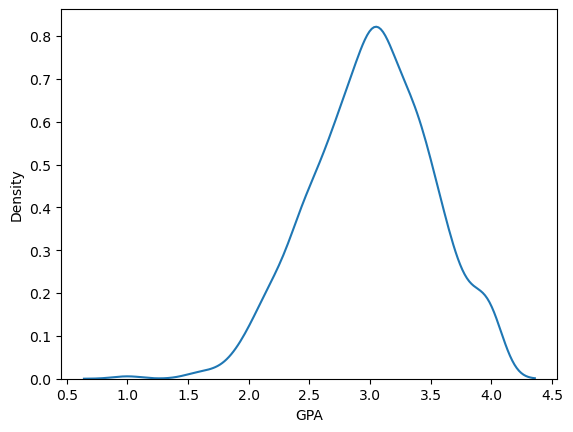

In [69]:
sns.kdeplot(students['GPA'])

<Axes: xlabel='GPA', ylabel='Density'>

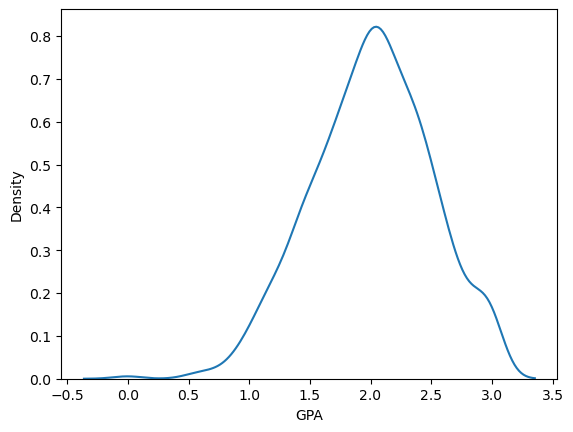

In [70]:
sns.kdeplot(students_scaled['GPA'])

Plotting the kernel density for the original and scaled data taking a column say GPA, it can be realised that mean normalization does not affect the default data distibution.

Maximum Absolute Scaling
In this feature scaling, each datapoint is divided by the maximum value.

In [71]:
from sklearn.preprocessing import MaxAbsScaler
scaler=MaxAbsScaler()
scaler.fit(students_data)
students_scaled=scaler.transform(students_data)

In [72]:
students_scaled=pd.DataFrame(students_scaled,
columns=students_data.columns)
students_scaled.head()                    

,Assignment_Score,Exam_Score,Study_Hours_per_Week,Family_Income,GPA
0,0.711071,0.703456,0.038441,0.007306,0.832590
1,0.629187,0.258175,0.143712,0.013131,0.779258
2,0.582980,0.673478,0.317702,0.018694,0.712959
3,0.657460,0.422428,0.012952,0.006968,0.761327
4,0.457257,0.801652,0.062646,0.014329,0.609731


<Axes: xlabel='Exam_Score', ylabel='Density'>

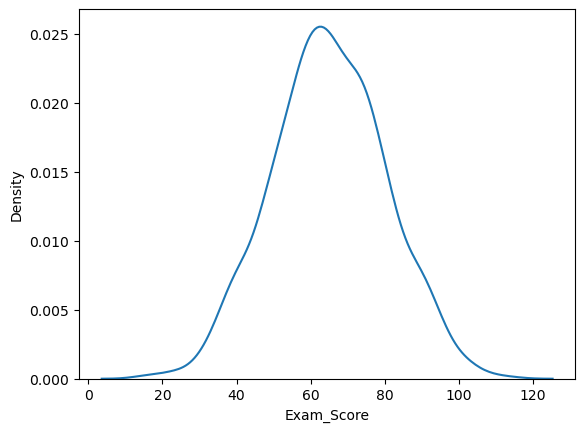

In [73]:
sns.kdeplot(students['Exam_Score'])

<Axes: xlabel='Exam_Score', ylabel='Density'>

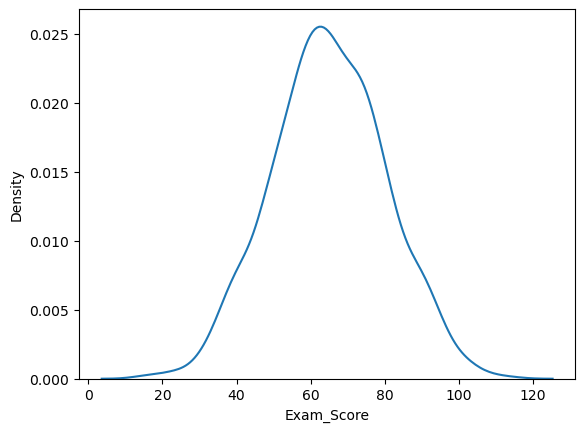

In [74]:
sns.kdeplot(students_data['Exam_Score'])

Plotting the kernel density for the original and scaled data taking a column say Exam_Score, it can be realised that maximum absolute scaling does not affect the default data distibution.

Median and Quantile Scaling
With this, the mean of the dataset is substracted from all the data values and the results divided by the difference of the first and third quantiles


In [75]:
from sklearn.preprocessing import RobustScaler
scaler=RobustScaler()
scaler.fit(students_data)
students_scaled=scaler.transform(students_data)

In [76]:
students_scaled=pd.DataFrame(students_scaled,
columns=students_data.columns)
students_scaled.head()      

,Assignment_Score,Exam_Score,Study_Hours_per_Week,Family_Income,GPA
0,0.399055,0.747161,0.097483,-0.594919,0.446563
1,-0.072968,-1.705434,2.095180,-0.039675,0.128231
2,-0.339337,0.582044,5.396937,0.490522,-0.267493
3,0.090011,-0.800731,-0.386202,-0.627131,0.021205
4,-1.064070,1.288024,0.556816,0.074504,-0.883637


<Axes: xlabel='Exam_Score', ylabel='Density'>

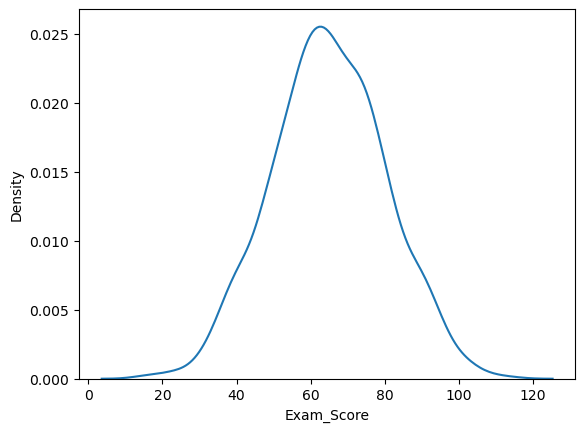

In [77]:
sns.kdeplot(students['Exam_Score'])

<Axes: xlabel='Exam_Score', ylabel='Density'>

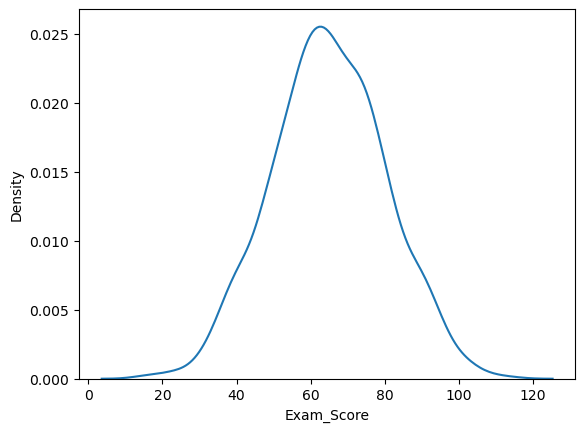

In [78]:
sns.kdeplot(students_data['Exam_Score'])

Plotting the kernel density for the original and scaled data taking a column say Exam_Score, it can be realised that mean and quantile scaling does not affect the default data distibution.

Vector Unt Length Scaling
With Vector Unit Length scaling, a new feature is created by dividing feature vactor by the manhattan distance or euclidean distance

In [79]:
from sklearn.preprocessing import Normalizer
students_data.dropna(inplace=True)
scaler=Normalizer(norm='l1')
scaler.fit(students_data)
students_scaled=scaler.transform(students_data)

C:\Users\Clement\AppData\Local\Temp\ipykernel_20740\2166752992.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  students_data.dropna(inplace=True)


In [80]:
students_scaled=pd.DataFrame(students_scaled,
columns=students_data.columns)
students_scaled.head()      

,Assignment_Score,Exam_Score,Study_Hours_per_Week,Family_Income,GPA
0,0.005974,0.006311,0.000501,0.986952,0.000262
1,0.002963,0.001299,0.001050,0.994551,0.000137
2,0.001928,0.002378,0.001629,0.993977,0.000088
3,0.005808,0.003985,0.000177,0.989778,0.000252
4,0.001972,0.003693,0.000419,0.993818,0.000098


<Axes: xlabel='Family_Income', ylabel='Density'>

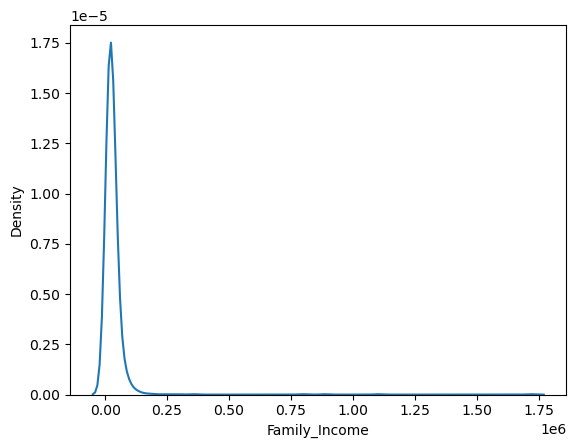

In [81]:
sns.kdeplot(students['Family_Income'])

<Axes: xlabel='Family_Income', ylabel='Density'>

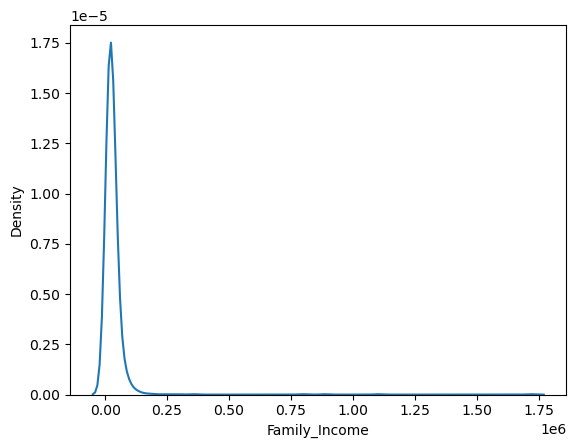

In [82]:
sns.kdeplot(students_data['Family_Income'])

Plotting the kernel density for the original and scaled data taking a column say Family_Income, it can be realised that Vector Unit Length scaling does not affect the default data distibution.

Task 7: Handling Imbalanced Datasets

Imbalanced datasets are a problem in predictive modeling because it can cause biases towards the majority values, leading to inaccuracy when predicting the minority values.

First we drop categorical columns and non-essential identifier columns to reduce the dimensionality and also prevent the model from breaking.



In [83]:
students.head(5)

,Student_ID,Gender,Programme,Year_of_Study,Admission_Type,Age,Attendance_Rate,Assignment_Score,Exam_Score,Study_Hours_per_Week,...,Accounting,Analytics,Business,Economics,MIS,Laptop,Mobile,Tablet,Stress_Level_Encoded,gpa_bins
0,10001,Male,Analytics,3,Regular,25,70.828212,76.000473,80.296648,6.372859,...,0,1,0,0,0,0,0,1,1.0,Bin_no_3
1,10002,Female,Economics,2,Regular,21,69.942178,67.248610,29.469632,23.825097,...,0,0,0,1,0,0,1,0,2.0,Bin_no_3
2,10003,Male,Accounting,2,Mature,17,63.280549,62.309827,76.874813,52.669848,...,1,0,0,0,0,1,0,0,1.0,Bin_no_2
3,10004,Male,Economics,1,Regular,22,59.625115,70.270440,48.218508,2.147296,...,0,0,0,1,0,0,1,0,0.0,Bin_no_3
4,10005,Male,Analytics,2,Regular,23,92.749857,48.872435,91.505367,10.385678,...,0,1,0,0,0,1,0,0,0.0,Bin_no_2


In [84]:
students = students.drop("Student_ID", axis=1)
students = students.drop("Gender", axis=1)
students = students.drop("Programme", axis=1)
students = students.drop("Admission_Type", axis=1)
students = students.drop("Internet_Access", axis=1)
students = students.drop("Device_Type", axis=1)
students = students.drop("Stress_Level", axis=1)
students = students.drop("Scholarship", axis=1)
students = students.drop("Dropped_Out", axis=1)
students = students.drop("gpa_bins", axis=1)

In [85]:
students.head()

,Year_of_Study,Age,Attendance_Rate,Assignment_Score,Exam_Score,Study_Hours_per_Week,Family_Income,GPA,le_Gender,le_IA,...,Regular,Accounting,Analytics,Business,Economics,MIS,Laptop,Mobile,Tablet,Stress_Level_Encoded
0,3,25,70.828212,76.000473,80.296648,6.372859,12556.507447,3.330362,1,1,...,1,0,1,0,0,0,0,0,1,1.0
1,2,21,69.942178,67.248610,29.469632,23.825097,22569.129727,3.117031,0,1,...,1,0,0,0,1,0,0,1,0,2.0
2,2,17,63.280549,62.309827,76.874813,52.669848,32130.094647,2.851835,1,1,...,0,1,0,0,0,0,1,0,0,1.0
3,1,22,59.625115,70.270440,48.218508,2.147296,11975.627487,3.045307,1,1,...,1,0,0,0,1,0,0,1,0,0.0
4,2,23,92.749857,48.872435,91.505367,10.385678,24628.109128,2.438924,1,1,...,1,0,1,0,0,0,1,0,0,0.0


In [86]:
students.shape

(1200, 24)

<Axes: xlabel='count', ylabel='le_DO'>

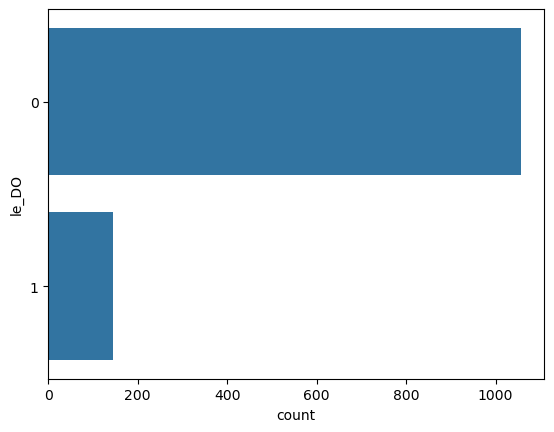

In [87]:
sns.countplot(y="le_DO", data=students)

In [88]:
students["le_DO"].value_counts()

le_DO
0    1056
1     144
Name: count, dtype: int64

Then we apply SMOTE Upsampling to balance the dataset:

In [89]:
y = students[['le_DO']]
X = students.drop("le_DO", axis = 1)
y["le_DO"].value_counts()

le_DO
0    1056
1     144
Name: count, dtype: int64

In [93]:
!pip install imbalanced-learn

In [95]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=2)
X_us, y_us = sm.fit_resample(X, y)

In [91]:
y_us["le_DO"].value_counts()

le_DO
0    1056
1    1056
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='le_DO'>

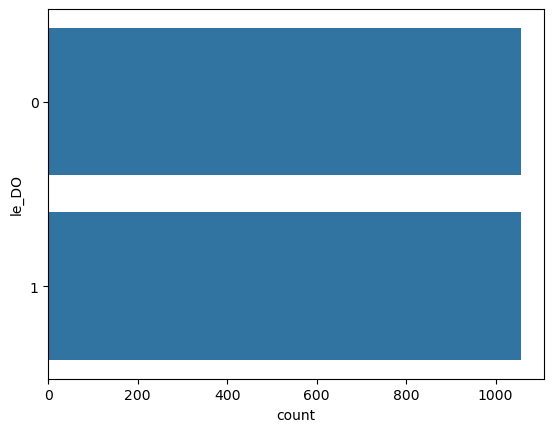

In [92]:
sns.countplot(y="le_DO", data=y_us)

In [96]:
final_df=pd.concat([X_us,y_us], axis=1)
final_df.head()

,Year_of_Study,Age,Attendance_Rate,Assignment_Score,Exam_Score,Study_Hours_per_Week,Family_Income,GPA,le_Gender,le_IA,...,Accounting,Analytics,Business,Economics,MIS,Laptop,Mobile,Tablet,Stress_Level_Encoded,le_DO
0,3,25,70.828212,76.000473,80.296648,6.372859,12556.507447,3.330362,1,1,...,0,1,0,0,0,0,0,1,1.0,0
1,2,21,69.942178,67.248610,29.469632,23.825097,22569.129727,3.117031,0,1,...,0,0,0,1,0,0,1,0,2.0,0
2,2,17,63.280549,62.309827,76.874813,52.669848,32130.094647,2.851835,1,1,...,1,0,0,0,0,1,0,0,1.0,1
3,1,22,59.625115,70.270440,48.218508,2.147296,11975.627487,3.045307,1,1,...,0,0,0,1,0,0,1,0,0.0,0
4,2,23,92.749857,48.872435,91.505367,10.385678,24628.109128,2.438924,1,1,...,0,1,0,0,0,1,0,0,0.0,0


In [100]:
final_df.to_excel('final_cleaned_students_data.xlsx', index=False)

1.Initial Exploration
 The stdents dataset was loaded, after the various datatypes were inspected and the mising values were checked for missing values.
 
2.Handling Missing Data
  We identified some missing values in the dataset and we used the end of tail value imputation for Assignment_Score and    Attendance_Rate because they had normal distribution and we used the mean imputation for Family_Income.

3.Categoriacal Data Encoding
We used  the labelencoding technique for Gender, Internet Access, Scholarship and the Dropped_Out colmns because these are binary variables whereas we used one hot encoding for Programme, Admission_Type and Device_Type because they have more than two variables. We also used ordinalencoding for the Stress_level because it had an inherent order.

4. Data Discretization
   With this, we discretized one continuos variable. We grouped the GPA column into bins of equal intervals.

5. Outlier Detection and Handling
   We detected the outliers using the box plot
   The triming method was used to remove the outliers from the Exam_Score column.

6. Feature Scaling
   With this, we applied all feature scaling methods taught in class which includes Standardization(Z score method), Normalization(Min/Max Scaling), Mean normailization, Maximum Absolute Scaling, Median and Quantile Scaling and the Vector Unit Length Scaling.

7. Handling imbalanced dataset
   With this, we dropped all categorical columns, non essential identified columns to improve the performance of the model and then we applied the SMOTE up sampling to balance the encoded dropped_out column to balance the dataset.